# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Justin Diamomd

**Date:** 9/1/2026

In [ ]:
# Question 1, Part 1
import pandas as pd

# Loading dataset
df_airbnb = pd.read_csv("./data/airbnb_hw.csv")

# Clean the Price column by converting to string, removing unneeded chars, and converting back
df_airbnb["Price_clean"] = (
    df_airbnb["Price"].astype(str).str.replace(r"[\$,]", "", regex=True)
)
df_airbnb["Price_clean"] = pd.to_numeric(
    df_airbnb["Price_clean"], errors="coerce"
)

# Count remaining missing
missing_count = df_airbnb["Price_clean"].isna().sum()
print(f"Total missing values in Price_clean: {missing_count}")

# Save 
df_airbnb.to_csv("./data/airbnb_clean.csv", index=False)

Total missing values in Price_clean: 0


In [3]:
# Question 1, Part 2
df_police = pd.read_csv("./data/mn_police_use_of_force.csv")

# Clean subject_injury
df_police["subject_injury_clean"] = (
    df_police["subject_injury"]
    .replace("", pd.NA)
    .str.strip()
)

missing_count = df_police["subject_injury_clean"].isna().sum()
missing_prop = df_police["subject_injury_clean"].isna().mean()
print(f"Missing count: {missing_count}")
print(f"Missing proportion: {missing_prop:.3f}")

# Check cleaned values
print(df_police["subject_injury_clean"].value_counts(dropna=False))

# Cross check with force_type
print("\nCross-tabulated: force_type vs subject_injury_clean")
print(pd.crosstab(
    df_police["force_type"],
    df_police["subject_injury_clean"],
    margins=True,
    dropna=False
))

# Missing rate by force type
print("\nMissing rate by force_type:")
print(
    df_police.groupby("force_type")["subject_injury_clean"]
    .apply(lambda x: x.isna().mean())
    .sort_values(ascending=False)
)

Missing count: 9848
Missing proportion: 0.762
subject_injury_clean
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Cross-tabulated: force_type vs subject_injury_clean
subject_injury_clean           No   Yes   NaN    All
force_type                                          
Baton                           0     2     2      4
Bodily Force                 1093  1286  7051   9430
Chemical Irritant             131    41  1421   1593
Firearm                         2     0     0      2
Gun Point Display              33    44    27    104
Improvised Weapon              34    40    74    148
Less Lethal                     0     0    87     87
Less Lethal Projectile          1     2     0      3
Maximal Restraint Technique     0     0   170    170
Police K9 Bite                  2    44    31     77
Taser                         150   172   985   1307
All                          1446  1631  9848  12925

Missing rate by force_type:
force_type
Less Lethal                    1.000

9,848 out of 12,925 rows are missing, which is about 76.2% of the rows of data. This is a concern because we can't reliably estimate injury rates. We can't conclude that the missing rows are "No" because it isn't explicitly written. Someone could make an error when calculating injury rates when counting "Yes" injury rates because they could divide by total rows not acknoledging missing data. The cross tabulation shows that missingness varies by type of force, and for less violent force types there are less reported injury status while more dangerous types have a higher rate. 

Year range (raw): 0.0 to 2026.0
Year range (cleaned): 0.0 to 2026.0
Missing years: 2

Attacks since 1940: 5581 total
Avg attacks per year (1940-1950): 29.6
Avg attacks per year (2010-2019): 124.9


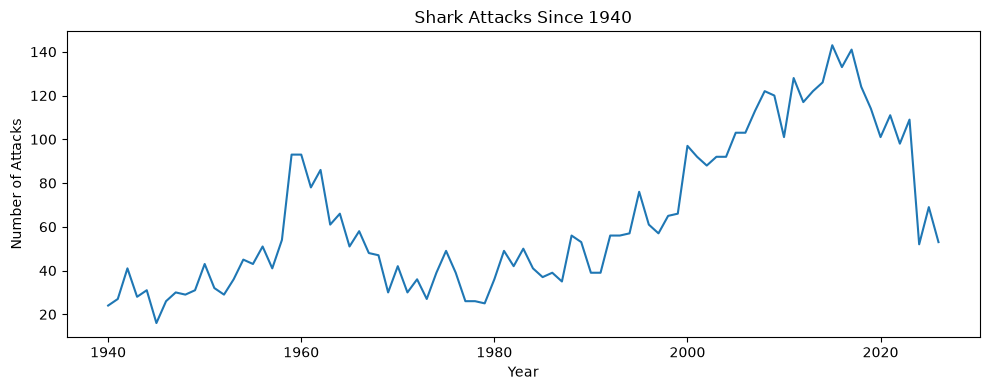


Valid ages: 3948 of 7117
count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64


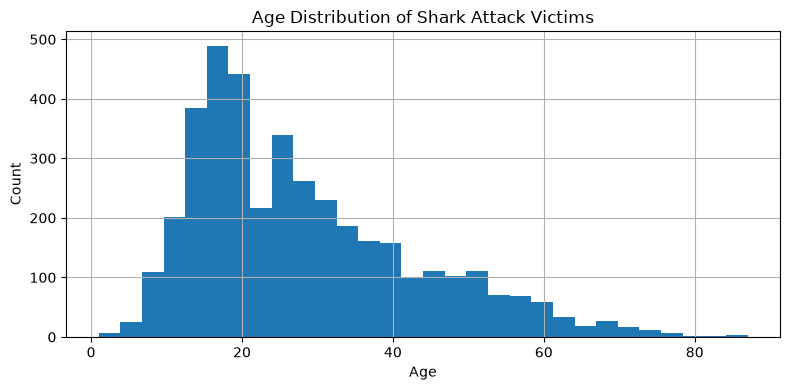


Proportion male (among known sex): 0.875
Sex_clean
M      5713
F       818
NaN     586
Name: count, dtype: int64

Type proportions:
Type_clean
Unprovoked    0.739497
Unknown       0.169313
Provoked      0.091190
Name: proportion, dtype: float64
Proportion unprovoked: 0.739


In [ ]:
# Question 2: Shark Attacks
import pandas as pd
import matplotlib.pyplot as plt

# Open the shark attack file 
df_shark = pd.read_excel("./data/GSAF5.xls")

# Drop columns that do not contain data
df_shark = df_shark.dropna(axis=1, how="all")
df_shark = df_shark.loc[:, ~df_shark.columns.str.startswith("Unnamed")]

# Clean the Year variable
df_shark["Year_clean"] = pd.to_numeric(df_shark["Year"], errors="coerce")

print("Year range (raw):", df_shark["Year"].min(), "to", df_shark["Year"].max())
print("Year range (cleaned):", df_shark["Year_clean"].min(), "to", df_shark["Year_clean"].max())
print("Missing years:", df_shark["Year_clean"].isna().sum())

# Filter to attacks since 1940
df_since_1940 = df_shark[df_shark["Year_clean"] >= 1940].copy()
attacks_by_year = df_since_1940.groupby("Year_clean").size()

print(f"\nAttacks since 1940: {len(df_since_1940)} total")
print(f"Avg attacks per year (1940-1950): {attacks_by_year.loc[1940:1950].mean():.1f}")
print(f"Avg attacks per year (2010-2019): {attacks_by_year.loc[2010:2019].mean():.1f}")

# Plot attacks over time to assess trend
attacks_by_year.plot(kind="line", figsize=(10, 4), title="Shark Attacks Since 1940")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()

# Clean the Age variable and make a histogram
df_shark["Age_clean"] = pd.to_numeric(df_shark["Age"], errors="coerce")

print(f"\nValid ages: {df_shark['Age_clean'].notna().sum()} of {len(df_shark)}")
print(df_shark["Age_clean"].describe())

df_shark["Age_clean"].dropna().hist(bins=30, figsize=(8, 4))
plt.title("Age Distribution of Shark Attack Victims")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Proportion of victims who are male
df_shark["Sex_clean"] = (
    df_shark["Sex"]
    .astype(str)
    .str.strip()
    .str.upper()
)
df_shark.loc[~df_shark["Sex_clean"].isin(["M", "F"]), "Sex_clean"] = pd.NA

known_sex = df_shark["Sex_clean"].notna()
male_prop = (df_shark.loc[known_sex, "Sex_clean"] == "M").mean()
print(f"\nProportion male: {male_prop:.3f}")
print(df_shark["Sex_clean"].value_counts(dropna=False))

# Clean Type
def clean_type(value):
    if pd.isna(value):
        return "Unknown"
    value = str(value).strip().lower()
    if "unprovoked" in value:
        return "Unprovoked"
    if "provoked" in value:
        return "Provoked"
    return "Unknown"

df_shark["Type_clean"] = df_shark["Type"].apply(clean_type)
type_counts = df_shark["Type_clean"].value_counts(normalize=True)
unprovoked_prop = (df_shark["Type_clean"] == "Unprovoked").mean()

print(f"\nType proportions:")
print(type_counts)
print(f"Proportion unprovoked: {unprovoked_prop:.3f}")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]